In [1]:
# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,449 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121689 files and dire

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

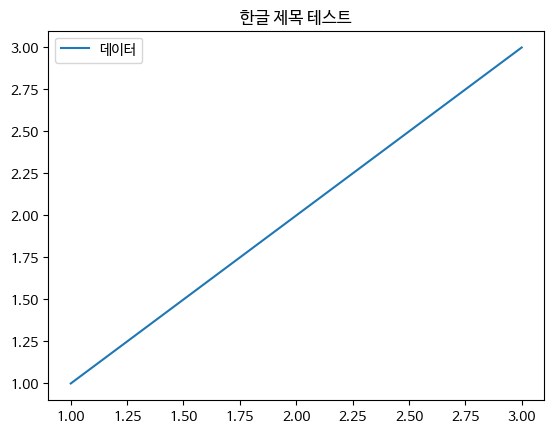

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. 설치된 폰트 등록 및 설정
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
    name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 확인용 테스트
plt.title("한글 제목 테스트")
plt.plot([1, 2, 3], [1, 2, 3], label="데이터")
plt.legend()
plt.show()

In [6]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/ColabNotebooks/'
df = pd.read_csv(f'{base_path}cohort_csv/old/4. data.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:

# 컬럼 분류
id_cols = ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME']
demographic_cols = ['AGE_AT_ADMISSION', 'GENDER']
outcome_cols = ['HOSPITAL_EXPIRE_FLAG', 'SEPSIS']
vital_cols = ['HEART_RATE', 'SBP', 'DBP', 'MAP', 'RESP_RATE', 'TEMP', 'SPO2', 'FIO2', 'GCS']
lab_cols = ['WBC', 'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN',
            'GLUCOSE_CHART', 'GLUCOSE_LAB', 'INR', 'PT', 'PTT',
            'SODIUM', 'POTASSIUM', 'CHLORIDE', 'BICARBONATE', 'BILIRUBIN',
            'PAO2', 'CRP','CALCIUM']
urine_cols = ['URINE_PROTEIN', 'URINE_SPEC_GRAVITY', 'TOTAL_URINE_OUTPUT']
calculated_cols = ['SHOCK_INDEX', 'ANION_GAP_APPROX', 'BUN_CR_RATIO', 'MISSING_RATIO']
sofa_cols = [col for col in df.columns if 'SOFA' in col]

print("\n변수 분류:")
print(f"- ID 컬럼: {len(id_cols)}개")
print(f"- 인구통계: {len(demographic_cols)}개")
print(f"- 결과 변수: {len(outcome_cols)}개")
print(f"- 활력징후: {len(vital_cols)}개")
print(f"- 혈액검사: {len(lab_cols)}개")
print(f"- 소변검사: {len(urine_cols)}개")
print(f"- 계산 지표: {len(calculated_cols)}개")
print(f"- SOFA 점수: {len(sofa_cols)}개")

# Target 변수 확인
print("\n" + "-" * 80)
print("Target 변수 분포 (SEPSIS):")
print(df['SEPSIS'].value_counts())
print(f"\n패혈증 발생률: {df['SEPSIS'].mean()*100:.2f}%")

if 'HOSPITAL_EXPIRE_FLAG' in df.columns:
    print("\n사망률:")
    print(df['HOSPITAL_EXPIRE_FLAG'].value_counts())
    print(f"전체 사망률: {df['HOSPITAL_EXPIRE_FLAG'].mean()*100:.2f}%")

    # 패혈증별 사망률
    mortality_by_sepsis = df.groupby('SEPSIS')['HOSPITAL_EXPIRE_FLAG'].agg(['sum', 'count', 'mean'])
    mortality_by_sepsis.columns = ['사망자수', '전체환자수', '사망률']
    mortality_by_sepsis['사망률'] = mortality_by_sepsis['사망률'] * 100
    print("\n패혈증 유무별 사망률:")
    print(mortality_by_sepsis)



변수 분류:
- ID 컬럼: 3개
- 인구통계: 2개
- 결과 변수: 2개
- 활력징후: 9개
- 혈액검사: 19개
- 소변검사: 3개
- 계산 지표: 4개
- SOFA 점수: 1개

--------------------------------------------------------------------------------
Target 변수 분포 (SEPSIS):
SEPSIS
0    40509
1     2662
Name: count, dtype: int64

패혈증 발생률: 6.17%

사망률:
HOSPITAL_EXPIRE_FLAG
0    41413
1     1758
Name: count, dtype: int64
전체 사망률: 4.07%

패혈증 유무별 사망률:
        사망자수  전체환자수        사망률
SEPSIS                        
0       1179  40509   2.910464
1        579   2662  21.750563



[3] 결측치 분석

결측치가 있는 변수: 35개

결측률 상위 20개 변수:
                      결측수  결측률(%)
CRP                 41361   95.81
FIO2                38938   90.19
PAO2                38314   88.75
URINE_PROTEIN       38140   88.35
TOTAL_URINE_OUTPUT  36705   85.02
GLUCOSE_CHART       36392   84.30
TEMP                35100   81.30
SPO2                34742   80.48
SHOCK_INDEX         34738   80.47
SBP                 34731   80.45
DBP                 34731   80.45
MAP                 34729   80.45
HEART_RATE          34695   80.37
RESP_RATE           34677   80.32
GCS                 33936   78.61
ALBUMIN             30090   69.70
URINE_SPEC_GRAVITY  27621   63.98
CALCIUM             27210   63.03
LACTATE             26379   61.10
BILIRUBIN           26134   60.54


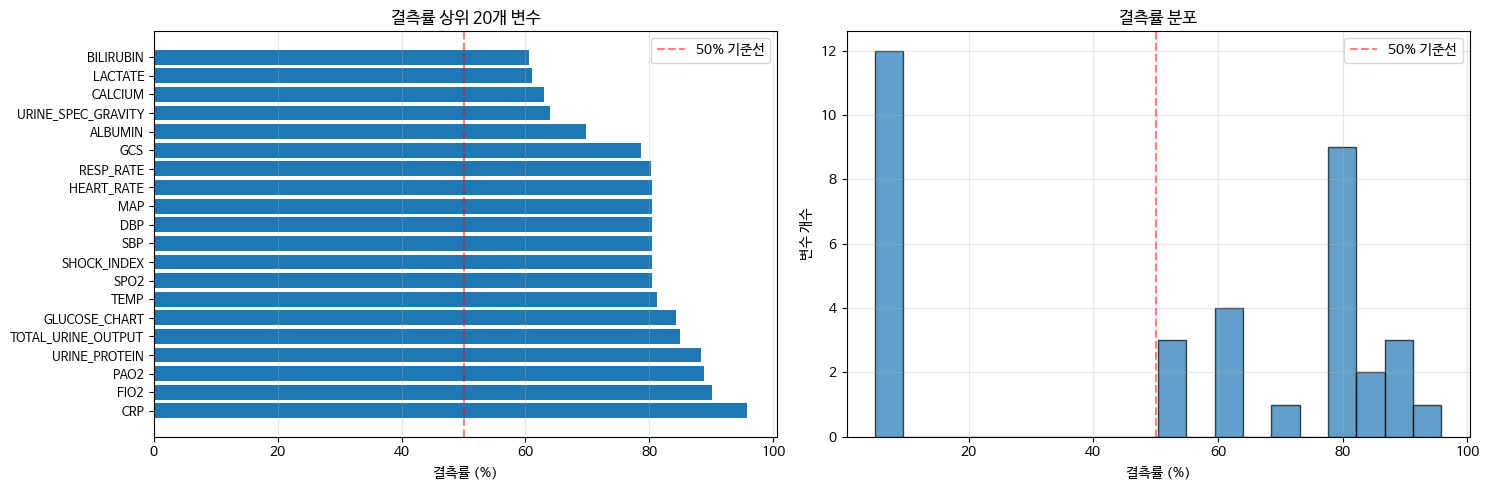


결측률 구간별 변수 개수:
  0-10%: 12개
  10-30%: 0개
  30-50%: 0개
  50-70%: 8개
  70%+: 15개


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 'data' DataFrame이 정의되지 않았으므로 다시 로드합니다.
data = pd.read_csv(f'{base_path}cohort_csv/old/4. data.csv')

# =============================================================================
# 3. 결측치 분석
# =============================================================================
print("\n" + "=" * 80)
print("[3] 결측치 분석")
print("=" * 80)

# 결측치 계산
missing_stats = pd.DataFrame({
    '결측수': data.isnull().sum(),
    '결측률(%)': (data.isnull().sum() / len(data) * 100).round(2)
})
missing_stats = missing_stats[missing_stats['결측수'] > 0].sort_values('결측률(%)', ascending=False)

print(f"\n결측치가 있는 변수: {len(missing_stats)}개")
print("\n결측률 상위 20개 변수:")
print(missing_stats.head(20))

# 결측률 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 결측률 막대그래프
if len(missing_stats) > 0:
    top_missing = missing_stats.head(20)
    axes[0].barh(range(len(top_missing)), top_missing['결측률(%)'])
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing.index, fontsize=9)
    axes[0].set_xlabel('결측률 (%)', fontsize=10)
    axes[0].set_title('결측률 상위 20개 변수', fontsize=12, fontweight='bold')
    axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)

# 결측률 히스토그램
axes[1].hist(missing_stats['결측률(%)'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('결측률 (%)', fontsize=10)
axes[1].set_ylabel('변수 개수', fontsize=10)
axes[1].set_title('결측률 분포', fontsize=12, fontweight='bold')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

# 결측률 그룹별 분류
missing_categories = {
    '0-10%': (missing_stats['결측률(%)'] <= 10).sum(),
    '10-30%': ((missing_stats['결측률(%)'] > 10) & (missing_stats['결측률(%)'] <= 30)).sum(),
    '30-50%': ((missing_stats['결측률(%)'] > 30) & (missing_stats['결측률(%)'] <= 50)).sum(),
    '50-70%': ((missing_stats['결측률(%)'] > 50) & (missing_stats['결측률(%)'] <= 70)).sum(),
    '70%+': (missing_stats['결측률(%)'] > 70).sum()
}

print("\n결측률 구간별 변수 개수:")
for category, count in missing_categories.items():
    print(f"  {category}: {count}개")

# MISSING_RATIO 변수 분석
# 'base_path'와 'cont_cols'가 정의되어 있지 않아 오류가 발생할 수 있으므로,
# 여기서는 'MISSING_RATIO' 컬럼만 확인합니다.
if 'MISSING_RATIO' in data.columns:
    print("\n환자별 결측률 (MISSING_RATIO) 통계:")
    print(data['MISSING_RATIO'].describe())

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(data['MISSING_RATIO'], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('환자별 결측률 (%)', fontsize=10)
    ax.set_ylabel('환자 수', fontsize=10)
    ax.set_title('환자별 결측률 분포', fontsize=12, fontweight='bold')
    ax.axvline(x=data['MISSING_RATIO'].median(), color='red', linestyle='--',
               label=f'중앙값: {data["MISSING_RATIO"].median():.1f}%')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('02_patient_missing_ratio.png', dpi=300, bbox_inches='tight')
    plt.show()

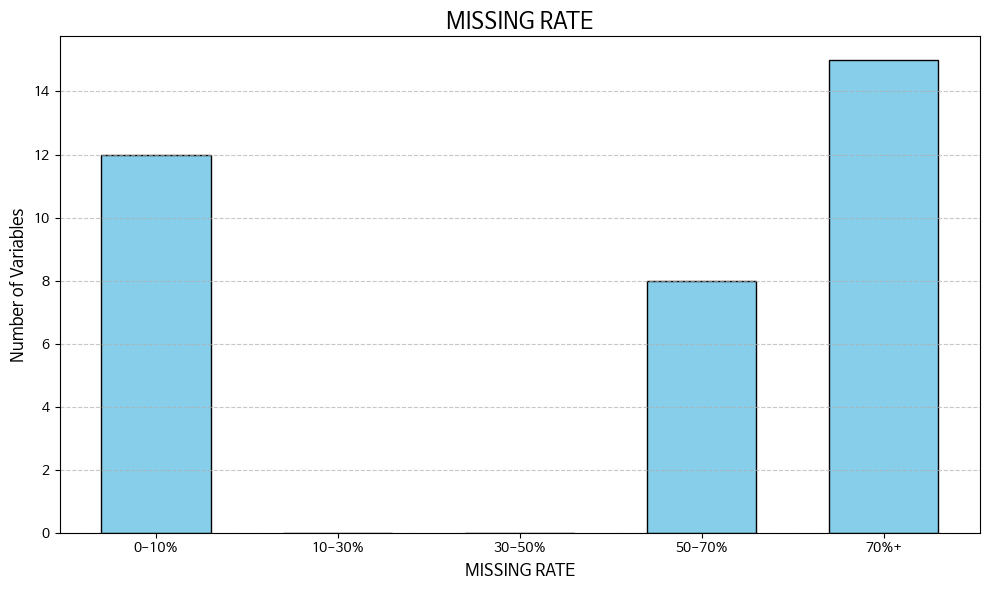

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Define missing_categories based on the previous output
missing_categories = {
    '0-10%': 12,
    '10-30%': 0,
    '30-50%': 0,
    '50-70%': 8,
    '70%+': 15
}

# Use all categories and their counts, so bars for 0 counts are also displayed as gaps
categories = list(missing_categories.keys())
counts = list(missing_categories.values())

plt.figure(figsize=(10, 6))
# Reduce bar width by setting 'width' parameter and use a single color
plt.bar(categories, counts, color='skyblue', edgecolor='black', width=0.6)
plt.title('MISSING RATE', fontsize=16, fontweight='bold')
plt.xlabel('MISSING RATE', fontsize=12)
plt.ylabel('Number of Variables', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print("\nALBUMIN 결측치 통계:")
print(missing_stats[missing_stats.index == 'ALBUMIN'])


[4] 인구통계 분석

나이 분포:
count    43171.000000
mean        58.793542
std         19.639866
min         18.000000
25%         45.000000
50%         60.000000
75%         74.000000
max        100.000000
Name: AGE_AT_ADMISSION, dtype: float64

성별 분포:
GENDER
F    22210
M    20961
Name: count, dtype: int64

성비 (M:F) = 20961 : 22210

패혈증 유무별 나이 차이 검정 (t-test):
  비패혈증 평균: 58.2세
  패혈증 평균: 67.1세
  p-value: 0.0000


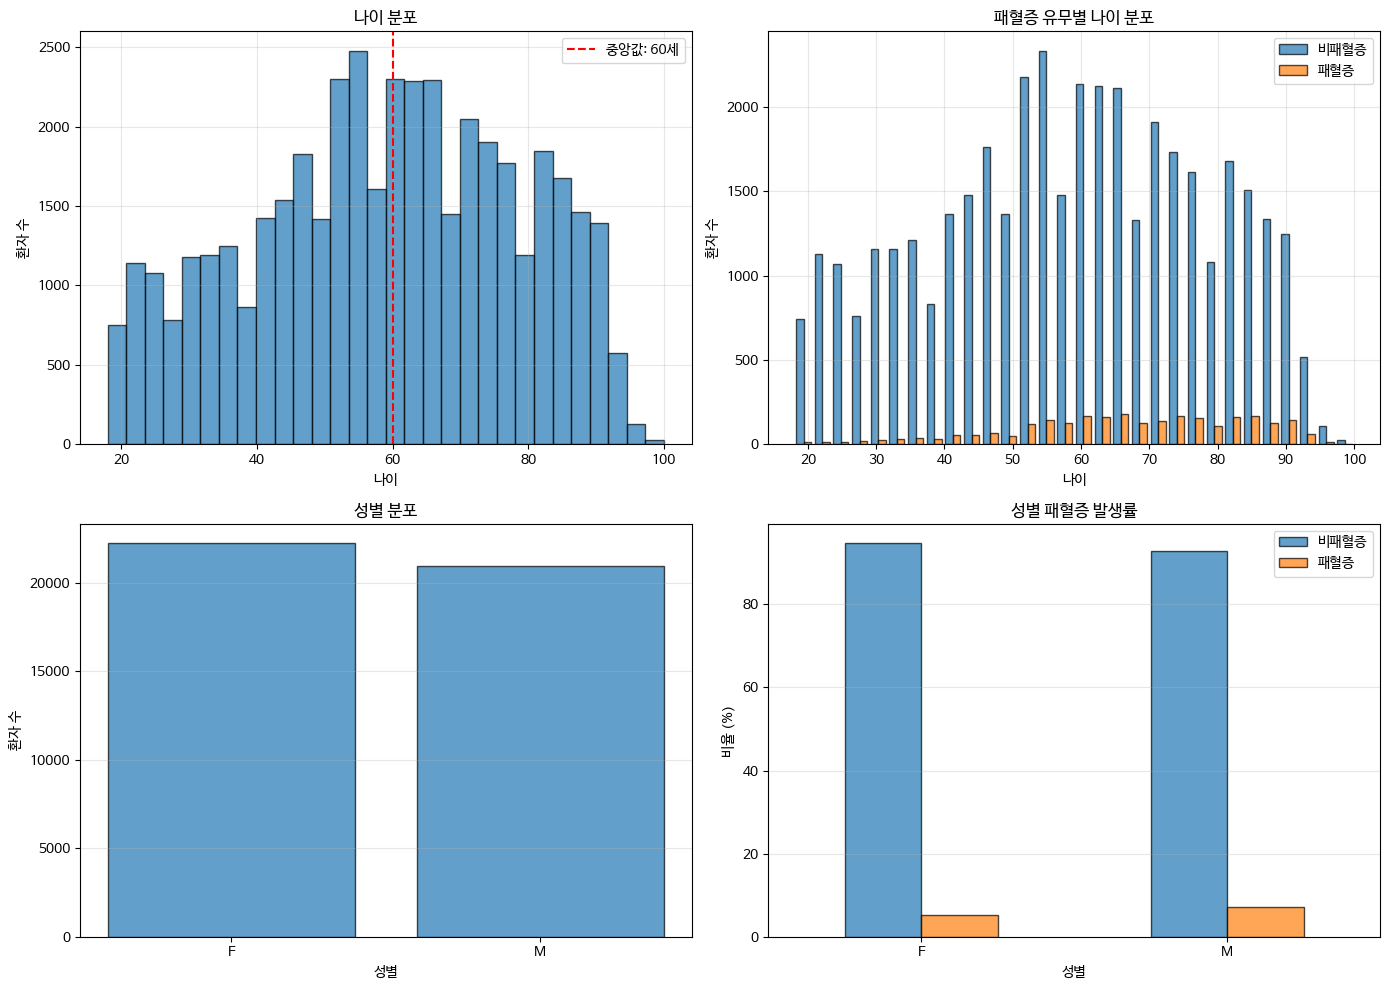

In [14]:
# =============================================================================
# 4. 인구통계 분석
# =============================================================================
print("\n" + "=" * 80)
print("[4] 인구통계 분석")
print("=" * 80)

# 나이 분포
print("\n나이 분포:")
print(df['AGE_AT_ADMISSION'].describe())

# 성별 분포
if 'GENDER' in df.columns:
    print("\n성별 분포:")
    print(df['GENDER'].value_counts())
    print(f"\n성비 (M:F) = {df['GENDER'].value_counts().get('M', 0)} : {df['GENDER'].value_counts().get('F', 0)}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 나이 히스토그램
axes[0, 0].hist(df['AGE_AT_ADMISSION'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('나이', fontsize=10)
axes[0, 0].set_ylabel('환자 수', fontsize=10)
axes[0, 0].set_title('나이 분포', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=df['AGE_AT_ADMISSION'].median(), color='red', linestyle='--',
                   label=f'중앙값: {df["AGE_AT_ADMISSION"].median():.0f}세')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 패혈증 유무별 나이 분포
if 'SEPSIS' in df.columns:
    sepsis_age = df[df['SEPSIS'] == 1]['AGE_AT_ADMISSION'].dropna()
    non_sepsis_age = df[df['SEPSIS'] == 0]['AGE_AT_ADMISSION'].dropna()

    axes[0, 1].hist([non_sepsis_age, sepsis_age], bins=30,
                    label=['비패혈증', '패혈증'], alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('나이', fontsize=10)
    axes[0, 1].set_ylabel('환자 수', fontsize=10)
    axes[0, 1].set_title('패혈증 유무별 나이 분포', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 통계 검정
    t_stat, p_value = stats.ttest_ind(non_sepsis_age, sepsis_age)
    print(f"\n패혈증 유무별 나이 차이 검정 (t-test):")
    print(f"  비패혈증 평균: {non_sepsis_age.mean():.1f}세")
    print(f"  패혈증 평균: {sepsis_age.mean():.1f}세")
    print(f"  p-value: {p_value:.4f}")

# 성별 분포
if 'GENDER' in df.columns:
    gender_counts = df['GENDER'].value_counts()
    axes[1, 0].bar(gender_counts.index, gender_counts.values, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('성별', fontsize=10)
    axes[1, 0].set_ylabel('환자 수', fontsize=10)
    axes[1, 0].set_title('성별 분포', fontsize=12, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 패혈증 유무별 성별 분포
    if 'SEPSIS' in df.columns:
        sepsis_gender = pd.crosstab(df['GENDER'], df['SEPSIS'], normalize='index') * 100
        sepsis_gender.plot(kind='bar', ax=axes[1, 1], edgecolor='black', alpha=0.7)
        axes[1, 1].set_xlabel('성별', fontsize=10)
        axes[1, 1].set_ylabel('비율 (%)', fontsize=10)
        axes[1, 1].set_title('성별 패혈증 발생률', fontsize=12, fontweight='bold')
        axes[1, 1].legend(['비패혈증', '패혈증'])
        axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
        axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_demographics.png', dpi=300, bbox_inches='tight')
plt.show()



[5] 활력징후 분석

활력징후 기술통계:
             count        mean        std        min     25%         50%  \
HEART_RATE  8476.0   88.073731  19.293061  27.166667   74.00   86.666667   
SBP         8440.0  122.778927  21.419264  51.600000  107.25  120.414286   
DBP         8440.0   67.990436  14.569172  17.000000   58.00   67.000000   
MAP         8442.0   81.572549  15.240617  25.000000   71.00   80.000000   
RESP_RATE   8494.0   19.663705   4.449405   7.000000   16.50   19.000000   
TEMP        8071.0   36.675753   0.927779  28.000000   36.00   37.000000   
SPO2        8429.0   97.310756   3.463615  26.600000   96.00   98.000000   
FIO2        4233.0   62.989731  22.355573  21.000000   45.00   50.000000   
GCS         9235.0    9.488035   5.627328   0.000000    4.00   10.000000   

                   75%         max  결측률(%)  
HEART_RATE  100.906250  168.166667   80.37  
SBP         135.666667  232.000000   80.45  
DBP          76.500000  157.000000   80.45  
MAP          90.666667  179.833333

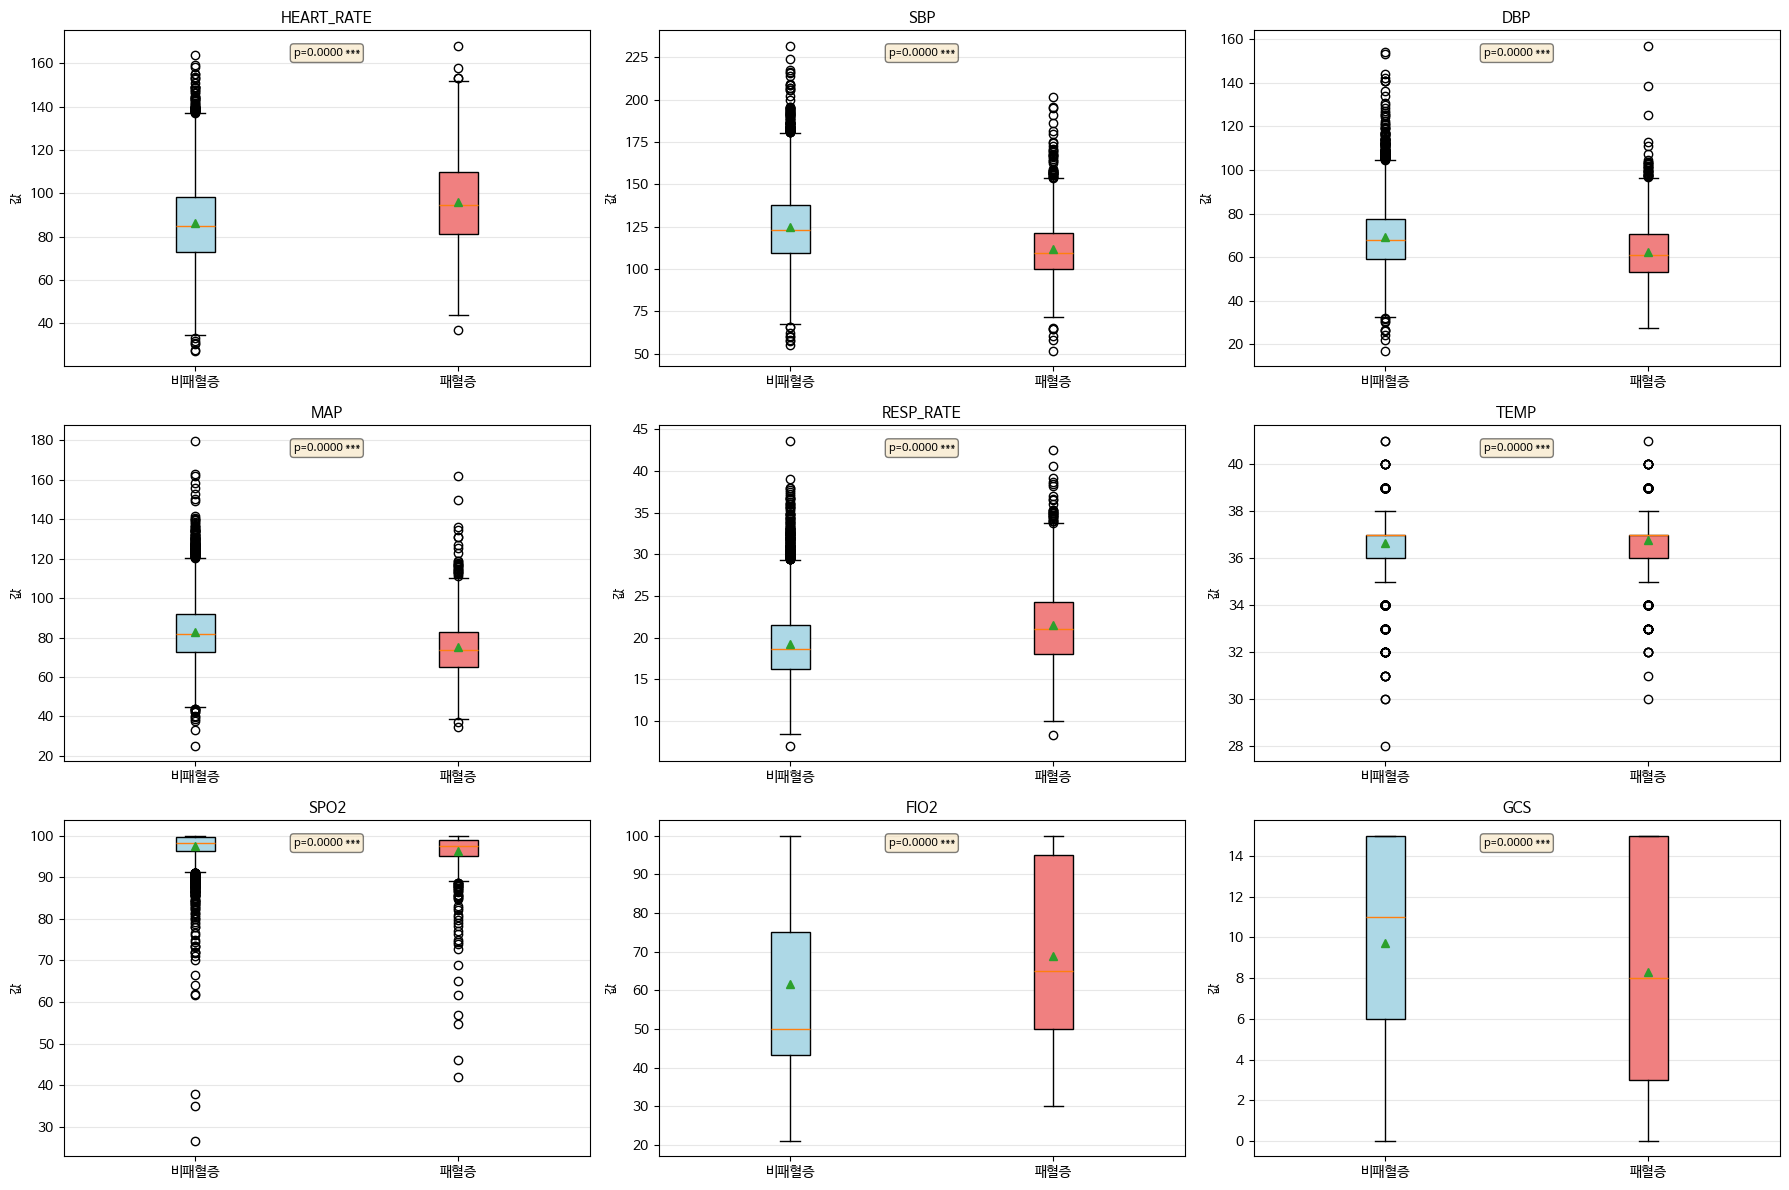

In [15]:
# =============================================================================
# 5. 활력징후 분석
# =============================================================================
print("\n" + "=" * 80)
print("[5] 활력징후 분석")
print("=" * 80)

vital_analysis = df[vital_cols].describe().T
vital_analysis['결측률(%)'] = (df[vital_cols].isnull().sum() / len(df) * 100).round(2)
print("\n활력징후 기술통계:")
print(vital_analysis)

# 이상치 탐지 함수
def detect_outliers_iqr(data, multiplier=1.5):
    """IQR 방법으로 이상치 탐지"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

# 활력징후별 이상치 분석
print("\n활력징후 이상치 분석 (IQR 방법, 1.5배):")
outlier_summary = []
for col in vital_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        outliers, lower, upper = detect_outliers_iqr(df[col].dropna())
        outlier_count = outliers.sum()
        outlier_pct = (outlier_count / df[col].notna().sum() * 100)
        outlier_summary.append({
            '변수': col,
            '이상치 수': outlier_count,
            '이상치 비율(%)': round(outlier_pct, 2),
            '하한': round(lower, 2),
            '상한': round(upper, 2)
        })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

# 활력징후 분포 시각화
n_vitals = len([col for col in vital_cols if col in df.columns and df[col].notna().sum() > 0])
n_rows = (n_vitals + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
axes = axes.flatten() if n_vitals > 1 else [axes]

for idx, col in enumerate(vital_cols):
    if col in df.columns and df[col].notna().sum() > 0:
        ax = axes[idx]

        # 박스플롯과 바이올린 플롯 결합
        data_to_plot = [
            df[df['SEPSIS'] == 0][col].dropna(),
            df[df['SEPSIS'] == 1][col].dropna()
        ]

        bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
                        patch_artist=True, showmeans=True)

        # 색상 설정
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_ylabel('값', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        # 통계 검정
        if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
            stat, p = stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            ax.text(0.5, 0.95, f'p={p:.4f} {sig}',
                   transform=ax.transAxes, ha='center', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

# 빈 subplot 제거
for idx in range(n_vitals, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('04_vital_signs.png', dpi=300, bbox_inches='tight')
plt.show()



[6] 혈액검사 분석

혈액검사 기술통계 (상위 10개):
                 count        mean         std   min    25%    50%    75%  \
WBC            40304.0   10.069322    8.791643   0.1    6.6    8.8   11.9   
HB             40304.0   12.199095    2.196590   3.2   10.8   12.4   13.7   
PLATELET       40283.0  252.777872  114.544398   5.0  184.0  238.0  303.0   
LACTATE        16792.0    2.099128    1.653259   0.0    1.2    1.7    2.4   
CREATININE     41023.0    1.288933    1.416654   0.0    0.7    0.9    1.2   
BUN            41002.0   21.683381   17.338538   1.0   12.0   17.0   25.0   
GLUCOSE_CHART   6779.0  168.590980   93.585239  20.0  110.0  139.0  193.0   
GLUCOSE_LAB    40575.0  137.504054   83.589407   5.0   97.0  113.0  145.0   
INR            21340.0    1.433613    0.964120   0.7    1.0    1.1    1.4   
PT             21349.0   15.736698    9.988880   8.3   11.6   12.8   15.1   

                  max  결측률(%)  
WBC             797.4    6.64  
HB               20.0    6.64  
PLATELET       2947.0 

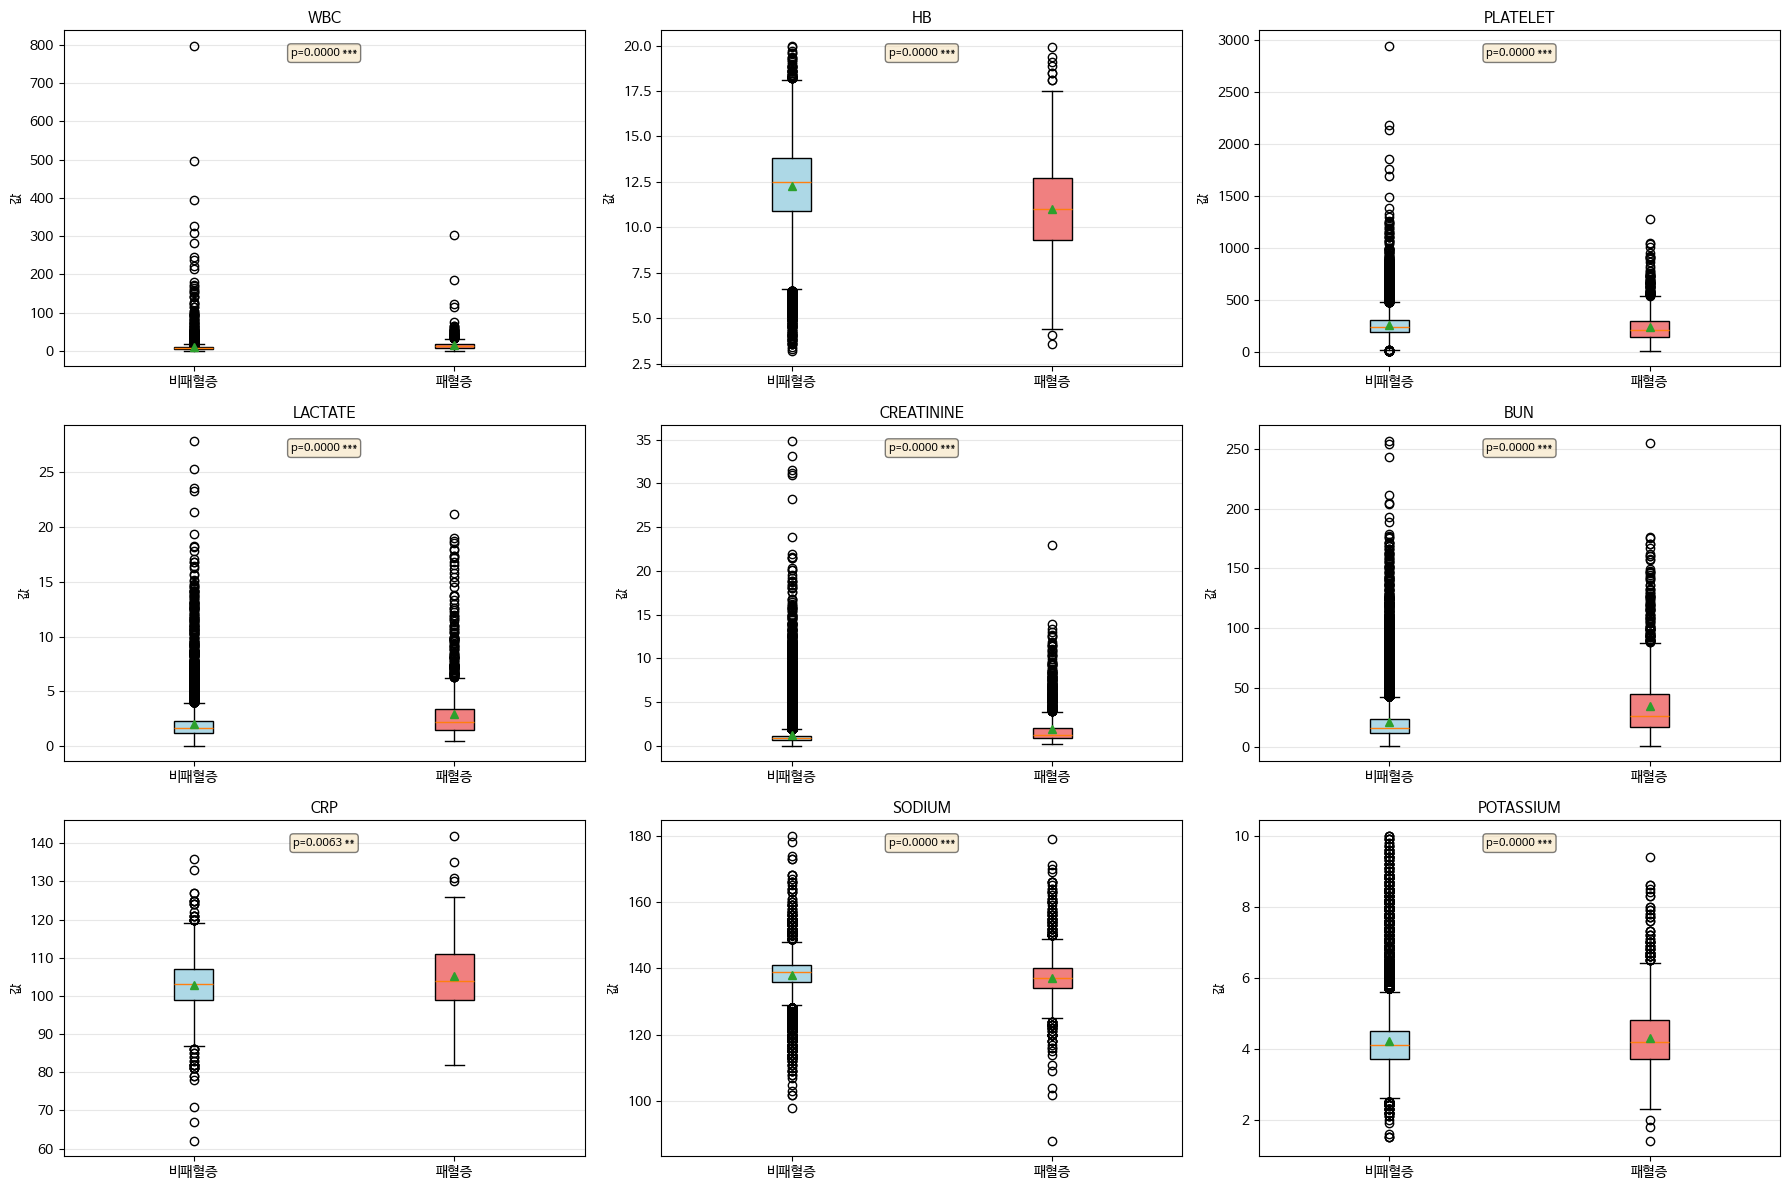

In [16]:
# =============================================================================
# 6. 혈액검사 분석
# =============================================================================
print("\n" + "=" * 80)
print("[6] 혈액검사 분석")
print("=" * 80)

lab_analysis = df[lab_cols].describe().T
lab_analysis['결측률(%)'] = (df[lab_cols].isnull().sum() / len(df) * 100).round(2)
print("\n혈액검사 기술통계 (상위 10개):")
print(lab_analysis.head(10))

# 주요 혈액검사 항목 시각화
key_labs = ['WBC', 'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN',
            'CRP', 'SODIUM', 'POTASSIUM']
available_key_labs = [col for col in key_labs if col in df.columns and df[col].notna().sum() > 0]

n_labs = len(available_key_labs)
n_rows = (n_labs + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
axes = axes.flatten() if n_labs > 1 else [axes]

for idx, col in enumerate(available_key_labs):
    ax = axes[idx]

    data_to_plot = [
        df[df['SEPSIS'] == 0][col].dropna(),
        df[df['SEPSIS'] == 1][col].dropna()
    ]

    bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
                    patch_artist=True, showmeans=True)

    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('값', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 통계 검정
    if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
        stat, p = stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(0.5, 0.95, f'p={p:.4f} {sig}',
               transform=ax.transAxes, ha='center', va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=8)

# 빈 subplot 제거
for idx in range(n_labs, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('05_lab_tests.png', dpi=300, bbox_inches='tight')
plt.show()


[7] 패혈증 관련 주요 지표 분석

SOFA 점수 분석:
              count      mean       std  min  25%  50%  75%   max
SOFA_TOTAL  43171.0  1.609228  2.685576  0.0  0.0  0.0  2.0  20.0

패혈증 유무별 SOFA_TOTAL 점수:

비패혈증:
  평균: 1.40
  중앙값: 0.00
  표준편차: 2.41

패혈증:
  평균: 4.82
  중앙값: 4.00
  표준편차: 4.16


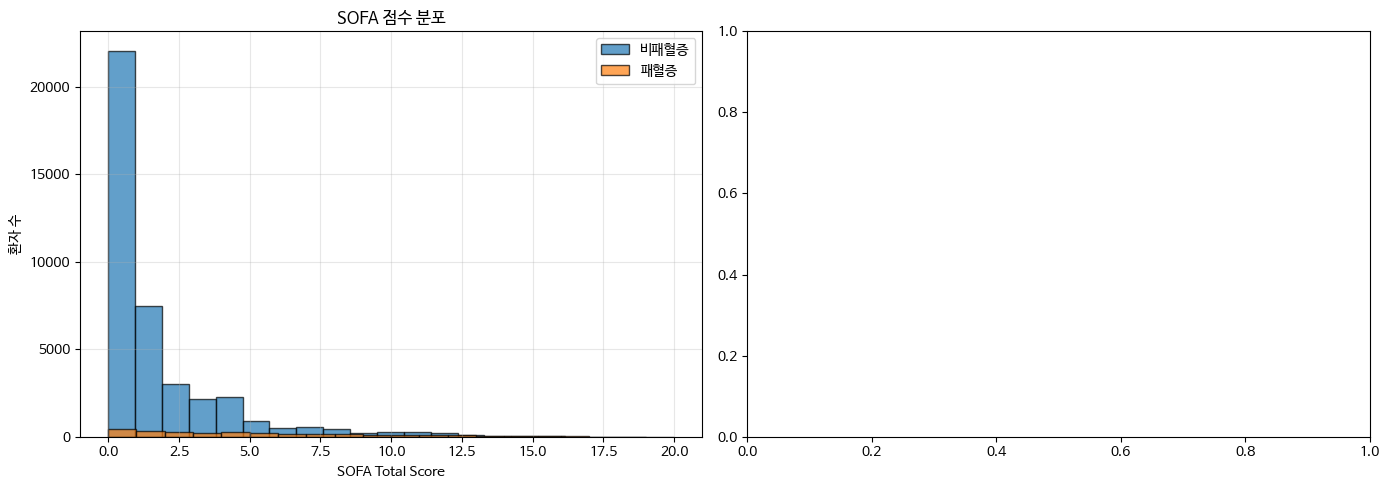

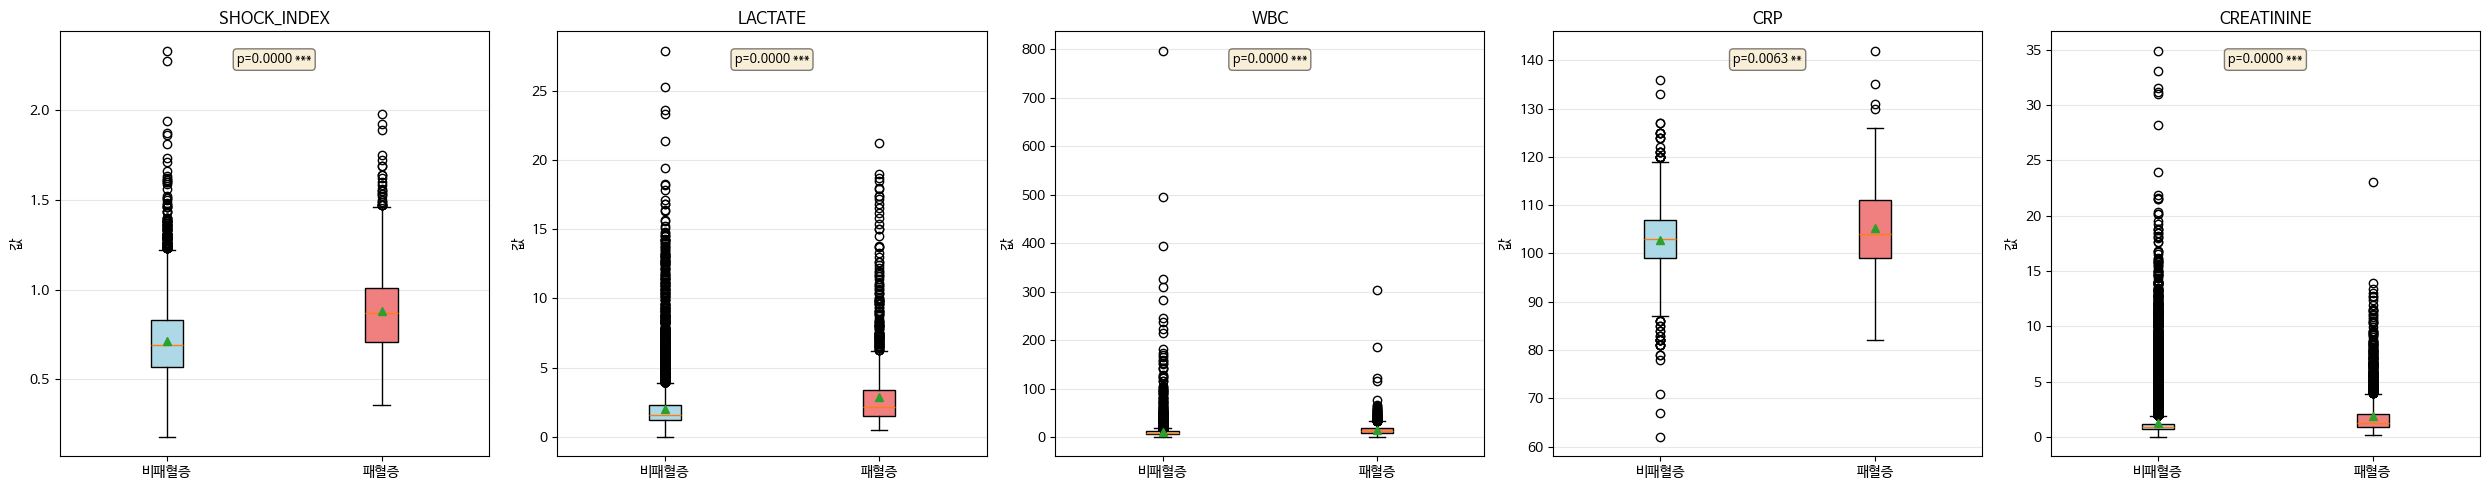

In [17]:
# =============================================================================
# 7. 패혈증 예측 관련 주요 지표 분석
# =============================================================================
print("\n" + "=" * 80)
print("[7] 패혈증 관련 주요 지표 분석")
print("=" * 80)

# SOFA 점수 분석
if len(sofa_cols) > 0:
    print("\nSOFA 점수 분석:")
    sofa_stats = df[sofa_cols].describe().T
    print(sofa_stats)

    # 패혈증 유무별 SOFA 점수
    if 'SOFA_TOTAL' in df.columns:
        print("\n패혈증 유무별 SOFA_TOTAL 점수:")
        for sepsis_status in [0, 1]:
            label = "비패혈증" if sepsis_status == 0 else "패혈증"
            sofa_values = df[df['SEPSIS'] == sepsis_status]['SOFA_TOTAL'].dropna()
            print(f"\n{label}:")
            print(f"  평균: {sofa_values.mean():.2f}")
            print(f"  중앙값: {sofa_values.median():.2f}")
            print(f"  표준편차: {sofa_values.std():.2f}")

        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # SOFA 점수 분포
        df[df['SEPSIS'] == 0]['SOFA_TOTAL'].hist(ax=axes[0], bins=20, alpha=0.7,
                                                   label='비패혈증', edgecolor='black')
        df[df['SEPSIS'] == 1]['SOFA_TOTAL'].hist(ax=axes[0], bins=20, alpha=0.7,
                                                   label='패혈증', edgecolor='black')
        axes[0].set_xlabel('SOFA Total Score', fontsize=10)
        axes[0].set_ylabel('환자 수', fontsize=10)
        axes[0].set_title('SOFA 점수 분포', fontsize=12, fontweight='bold')
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # SOFA 구성요소 비교
        sofa_components = [col for col in sofa_cols if col != 'SOFA_TOTAL']
        if len(sofa_components) > 0:
            sepsis_sofa = df[df['SEPSIS'] == 1][sofa_components].mean()
            non_sepsis_sofa = df[df['SEPSIS'] == 0][sofa_components].mean()

            x = np.arange(len(sofa_components))
            width = 0.35

            axes[1].bar(x - width/2, non_sepsis_sofa, width, label='비패혈증', alpha=0.7)
            axes[1].bar(x + width/2, sepsis_sofa, width, label='패혈증', alpha=0.7)
            axes[1].set_xlabel('SOFA 구성요소', fontsize=10)
            axes[1].set_ylabel('평균 점수', fontsize=10)
            axes[1].set_title('SOFA 구성요소별 평균 점수', fontsize=12, fontweight='bold')
            axes[1].set_xticks(x)
            axes[1].set_xticklabels([col.replace('SOFA_', '') for col in sofa_components],
                                   rotation=45, ha='right', fontsize=9)
            axes[1].legend()
            axes[1].grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('06_sofa_scores.png', dpi=300, bbox_inches='tight')
        plt.show()

# Shock Index, Lactate 등 주요 지표
key_indicators = ['SHOCK_INDEX', 'LACTATE', 'WBC', 'CRP', 'CREATININE']
available_indicators = [col for col in key_indicators if col in df.columns]

if len(available_indicators) > 0:
    fig, axes = plt.subplots(1, len(available_indicators), figsize=(5*len(available_indicators), 5))
    if len(available_indicators) == 1:
        axes = [axes]

    for idx, col in enumerate(available_indicators):
        data_to_plot = [
            df[df['SEPSIS'] == 0][col].dropna(),
            df[df['SEPSIS'] == 1][col].dropna()
        ]

        bp = axes[idx].boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
                               patch_artist=True, showmeans=True)

        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        axes[idx].set_title(col, fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('값', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

        # 통계 검정
        if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
            stat, p = stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            axes[idx].text(0.5, 0.95, f'p={p:.4f} {sig}',
                          transform=axes[idx].transAxes, ha='center', va='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                          fontsize=9)

    plt.tight_layout()
    plt.savefig('07_key_indicators.png', dpi=300, bbox_inches='tight')
    plt.show()



[8] 상관관계 분석

상관관계 분석 대상 변수: 15개

SEPSIS와의 상관관계 (상위 20개):
SOFA_TOTAL          0.306416
BUN                 0.181982
WBC                 0.125806
AGE_AT_ADMISSION    0.108733
CREATININE          0.105530
ANION_GAP_APPROX    0.100722
BUN_CR_RATIO        0.082789
GLUCOSE_LAB         0.072752
POTASSIUM           0.031419
CHLORIDE            0.013893
PLATELET           -0.036713
SODIUM             -0.043145
HB                 -0.128701
BICARBONATE        -0.156047
Name: SEPSIS, dtype: float64

SEPSIS와의 상관관계 (하위 20개):
SOFA_TOTAL          0.306416
BUN                 0.181982
WBC                 0.125806
AGE_AT_ADMISSION    0.108733
CREATININE          0.105530
ANION_GAP_APPROX    0.100722
BUN_CR_RATIO        0.082789
GLUCOSE_LAB         0.072752
POTASSIUM           0.031419
CHLORIDE            0.013893
PLATELET           -0.036713
SODIUM             -0.043145
HB                 -0.128701
BICARBONATE        -0.156047
Name: SEPSIS, dtype: float64


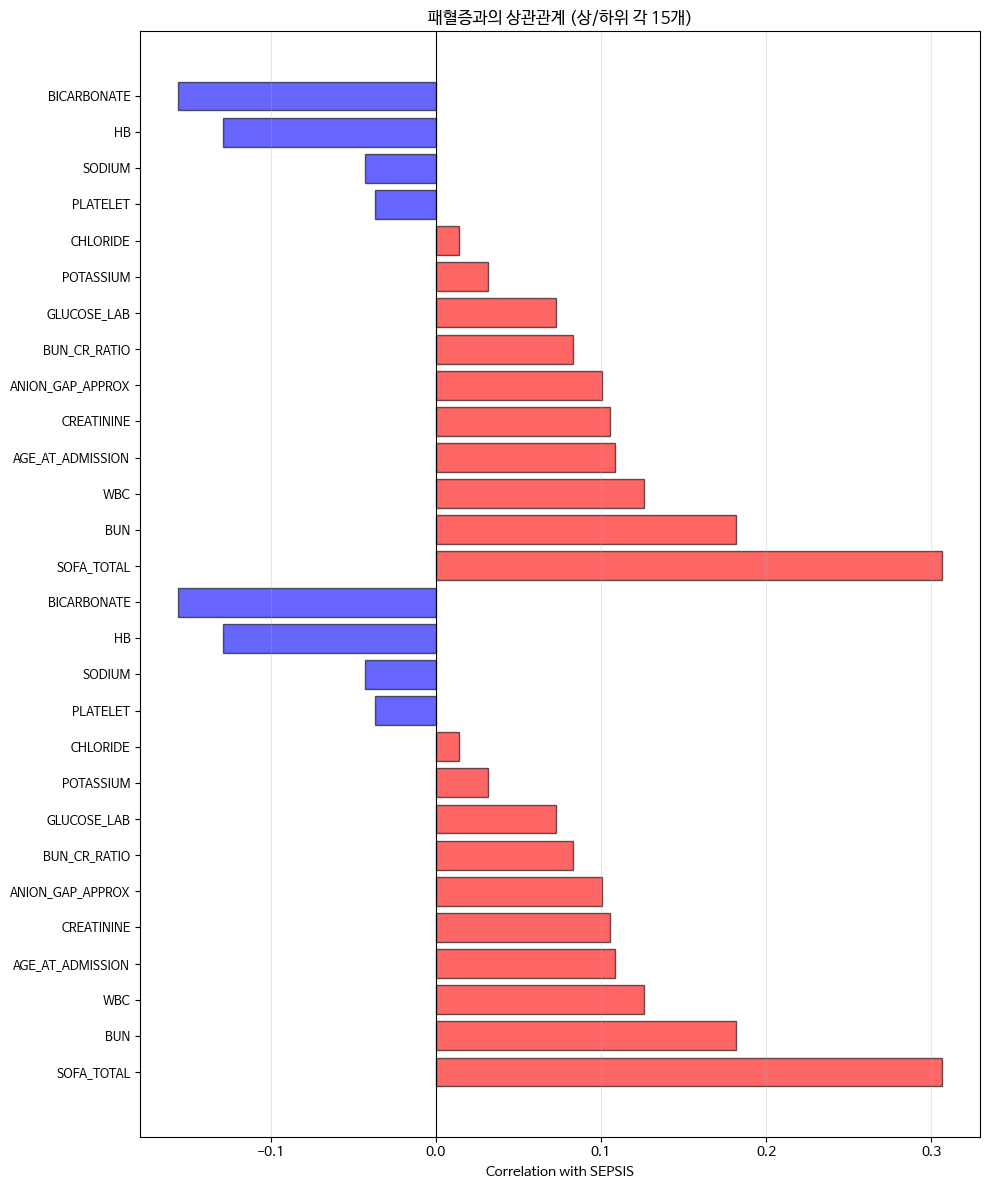

In [18]:
# =============================================================================
# 8. 상관관계 분석
# =============================================================================
print("\n" + "=" * 80)
print("[8] 상관관계 분석")
print("=" * 80)

# 수치형 변수만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# ID, outcome 제외
numeric_cols = [col for col in numeric_cols if col not in id_cols + ['HOSPITAL_EXPIRE_FLAG']]

# 결측률 50% 이하인 변수만 사용
# low_missing_cols에는 이미 'SEPSIS'가 포함되어 있으므로,
# 상관관계 계산 시 'SEPSIS' 컬럼을 중복으로 추가하지 않도록 수정합니다.
low_missing_cols = [col for col in numeric_cols
                    if df[col].isnull().sum() / len(df) < 0.5]

print(f"\n상관관계 분석 대상 변수: {len(low_missing_cols)}개")

# Target과의 상관관계
if 'SEPSIS' in df.columns:
    # low_missing_cols에는 이미 'SEPSIS'가 포함되어 있으므로 그대로 사용합니다.
    # .corr() 결과에서 'SEPSIS' 열을 선택하면 Series가 됩니다.
    correlations = df[low_missing_cols].corr()['SEPSIS']

    # 'SEPSIS' 자신과의 상관관계 (항상 1)는 제외합니다.
    correlations = correlations.drop('SEPSIS', errors='ignore') # errors='ignore'를 추가하여 'SEPSIS'가 없는 경우에도 에러 없이 처리

    # 상관관계 값을 기준으로 내림차순 정렬
    correlations = correlations.sort_values(ascending=False)

    print("\nSEPSIS와의 상관관계 (상위 20개):")
    print(correlations.head(20))

    print("\nSEPSIS와의 상관관계 (하위 20개):")
    print(correlations.tail(20))

    # 시각화
    fig, ax = plt.subplots(figsize=(10, 12))
    top_n = 30
    top_corr = pd.concat([correlations.head(top_n//2), correlations.tail(top_n//2)])

    colors = ['red' if x > 0 else 'blue' for x in top_corr.values]
    ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.6, edgecolor='black')
    ax.set_yticks(range(len(top_corr)))
    ax.set_yticklabels(top_corr.index, fontsize=9)
    ax.set_xlabel('Correlation with SEPSIS', fontsize=10)
    ax.set_title('패혈증과의 상관관계 (상/하위 각 15개)', fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('08_correlation_with_sepsis.png', dpi=300, bbox_inches='tight')
    plt.show()


히트맵 분석 대상 변수: 23개
선택된 변수 목록: ['AGE_AT_ADMISSION', 'WBC', 'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN', 'GLUCOSE_LAB', 'INR', 'PT', 'PTT', 'SODIUM', 'POTASSIUM', 'CHLORIDE', 'BICARBONATE', 'BILIRUBIN', 'ALBUMIN', 'CALCIUM', 'URINE_SPEC_GRAVITY', 'ANION_GAP_APPROX', 'BUN_CR_RATIO', 'SOFA_TOTAL', 'SEPSIS']


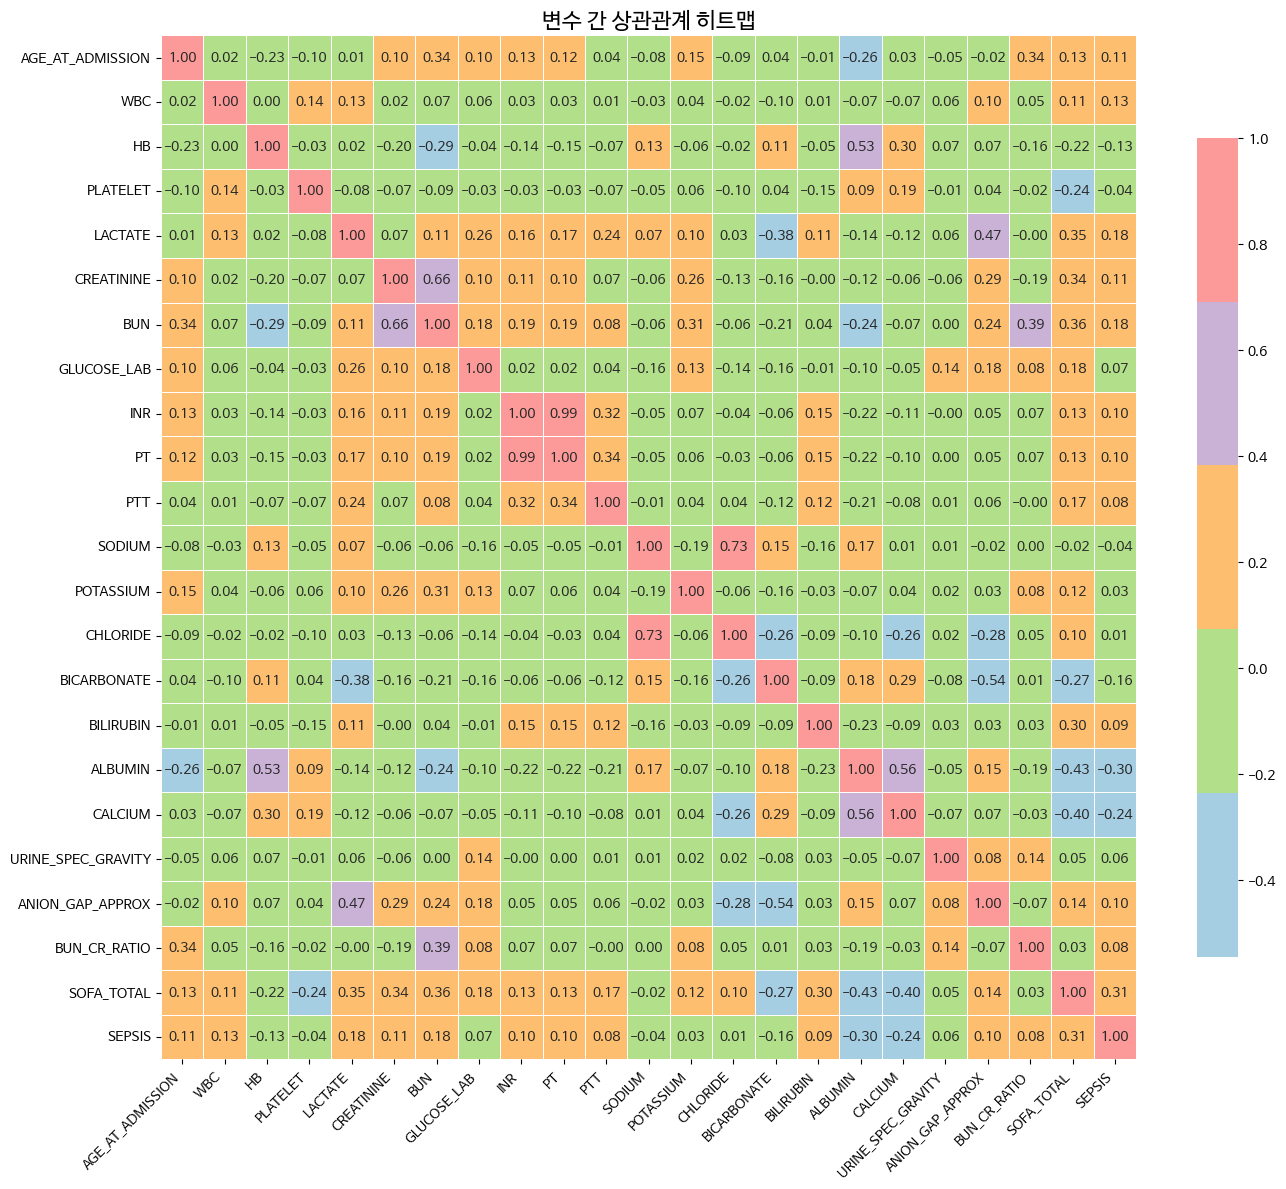

In [19]:
##### 상관관계 히트맵 #####

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # Custom colormap을 위해 추가

# 수치형 변수만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# ID, outcome 제외 (여기서는 SEPSIS는 포함하여 상관관계 계산)
numeric_cols = [col for col in numeric_cols if col not in id_cols + ['HOSPITAL_EXPIRE_FLAG']]

# 결측률 70% 미만인 변수만 사용
low_missing_cols_for_heatmap = [col for col in numeric_cols
                                if df[col].isnull().sum() / len(df) < 0.7]

print(f"\n히트맵 분석 대상 변수: {len(low_missing_cols_for_heatmap)}개")
print(f"선택된 변수 목록: {low_missing_cols_for_heatmap}")

# 상관관계 행렬 계산
correlation_matrix = df[low_missing_cols_for_heatmap].corr()

# 사용자 정의 색상 코드
custom_colors = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#CAB2D6', '#FB9A99']
custom_cmap = mcolors.ListedColormap(custom_colors)

# 히트맵 시각화
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix,
            annot=True, # 숫자 표시
            fmt=".2f", # 소수점 둘째 자리까지 표시
            cmap=custom_cmap, # 사용자 정의 색상 팔레트 적용
            linewidths=.5, # 선 간격
            cbar_kws={'shrink': .8}) # 컬러바 크기 조절
plt.title('변수 간 상관관계 히트맵', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('09_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# =============================================================================
# 9. 요약 및 권장사항
# =============================================================================
print("\n" + "=" * 80)
print("[9] EDA 요약 및 모델링 권장사항")
print("=" * 80)

print("\n📊 데이터 현황:")
print(f"  • 총 환자 수: {len(df):,}명")
print(f"  • 패혈증 발생률: {df['SEPSIS'].mean()*100:.2f}%")
print(f"  • 전체 변수 수: {len(df.columns)}개")
print(f"  • 수치형 변수: {len(numeric_cols)}개")

print("\n⚠️ 결측치 이슈:")
print(f"  • 결측치 있는 변수: {len(missing_stats)}개")
print(f"  • 결측률 50% 이상: {(missing_stats['결측률(%)'] > 50).sum()}개")
print(f"  • 결측률 70% 이상: {(missing_stats['결측률(%)'] > 70).sum()}개")

print("\n💡 모델링 권장사항:")
print("\n1. 변수 선택:")
print("   - 결측률 50% 이상 변수는 제외 검토")
print("   - SOFA 점수 변수들은 패혈증 진단에 이미 사용되므로 제외 고려")
print("   - 계산된 변수(SHOCK_INDEX 등)와 원본 변수(HEART_RATE, SBP 등) 중복 체크")

print("\n2. 결측치 처리:")
print("   - 활력징후: 의학적 정상값으로 대체 또는 중앙값 사용")
print("   - 혈액검사: Multiple Imputation 또는 MICE 알고리즘 고려")
print("   - 결측 여부 자체를 피처로 활용 (missing indicator)")

print("\n3. 이상치 처리:")
print("   - IQR 또는 도메인 지식 기반 범위 설정")
print("   - Winsorization (극단값 제한) 고려")
print("   - 로그 변환으로 분포 정규화")

print("\n4. 피처 엔지니어링:")
print("   - 활력징후 간 조합 (예: MAP, Shock Index)")
print("   - 비율 변수 (예: BUN/Cr ratio - 이미 존재)")
print("   - 범주화 (예: 나이 그룹, 중증도 등급)")

print("\n5. 클래스 불균형 처리:")
imbalance_ratio = (df['SEPSIS'] == 0).sum() / (df['SEPSIS'] == 1).sum()
print(f"   - 불균형 비율: {imbalance_ratio:.1f}:1")
print("   - SMOTE, ADASYN 등 오버샘플링 기법 고려")
print("   - Class weight 조정")
print("   - Stratified K-Fold 사용")

print("\n6. 모델 선택:")
print("   - XGBoost, LightGBM: 결측치 처리 가능, 해석 가능")
print("   - Random Forest: 강건한 성능")
print("   - Logistic Regression: 베이스라인, 해석 용이")
print("   - Neural Network: 복잡한 패턴 학습")

print("\n7. 평가 지표:")
print("   - AUROC, AUPRC (불균형 데이터에 적합)")
print("   - Sensitivity, Specificity")
print("   - F1-score, F2-score (재현율 중시)")

print("\n✅ EDA 완료!")
print("=" * 80)



[9] EDA 요약 및 모델링 권장사항

📊 데이터 현황:
  • 총 환자 수: 43,171명
  • 패혈증 발생률: 6.17%
  • 전체 변수 수: 43개
  • 수치형 변수: 38개

⚠️ 결측치 이슈:
  • 결측치 있는 변수: 35개
  • 결측률 50% 이상: 23개
  • 결측률 70% 이상: 15개

💡 모델링 권장사항:

1. 변수 선택:
   - 결측률 50% 이상 변수는 제외 검토
   - SOFA 점수 변수들은 패혈증 진단에 이미 사용되므로 제외 고려
   - 계산된 변수(SHOCK_INDEX 등)와 원본 변수(HEART_RATE, SBP 등) 중복 체크

2. 결측치 처리:
   - 활력징후: 의학적 정상값으로 대체 또는 중앙값 사용
   - 혈액검사: Multiple Imputation 또는 MICE 알고리즘 고려
   - 결측 여부 자체를 피처로 활용 (missing indicator)

3. 이상치 처리:
   - IQR 또는 도메인 지식 기반 범위 설정
   - Winsorization (극단값 제한) 고려
   - 로그 변환으로 분포 정규화

4. 피처 엔지니어링:
   - 활력징후 간 조합 (예: MAP, Shock Index)
   - 비율 변수 (예: BUN/Cr ratio - 이미 존재)
   - 범주화 (예: 나이 그룹, 중증도 등급)

5. 클래스 불균형 처리:
   - 불균형 비율: 15.2:1
   - SMOTE, ADASYN 등 오버샘플링 기법 고려
   - Class weight 조정
   - Stratified K-Fold 사용

6. 모델 선택:
   - XGBoost, LightGBM: 결측치 처리 가능, 해석 가능
   - Random Forest: 강건한 성능
   - Logistic Regression: 베이스라인, 해석 용이
   - Neural Network: 복잡한 패턴 학습

7. 평가 지표:
   - AUROC, AUPRC (불균형 데이터에 적합)
   - Sensitivity, Speci

In [21]:
# 결과 저장 # 시각화 코드 고치고 다시 저장할 것
# print("\n결과 파일:")
# print("  - 01_missing_values.png: 결측치 분석")
# print("  - 02_patient_missing_ratio.png: 환자별 결측률")
# print("  - 03_demographics.png: 인구통계")
# print("  - 04_vital_signs.png: 활력징후 분석")
# print("  - 05_lab_tests.png: 혈액검사 분석")
# print("  - 06_sofa_scores.png: SOFA 점수 분석")
# print("  - 07_key_indicators.png: 주요 지표 분석")
# print("  - 08_correlation_with_sepsis.png: 패혈증 상관관계")

In [23]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/ColabNotebooks/'
df = pd.read_csv(f'{base_path}cohort_csv/old/4. data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
vital_cols = ['HEART_RATE', 'SBP', 'DBP', 'MAP', 'RESP_RATE', 'TEMP', 'SPO2', 'FIO2', 'GCS']
lab_cols = ['WBC', 'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN',
            'GLUCOSE_CHART', 'GLUCOSE_LAB', 'INR', 'PT', 'PTT',
            'SODIUM', 'POTASSIUM', 'CHLORIDE', 'BICARBONATE', 'BILIRUBIN',
            'PAO2', 'CRP', 'CALCIUM']
urine_cols = ['URINE_PROTEIN', 'URINE_SPEC_GRAVITY', 'TOTAL_URINE_OUTPUT']
calculated_cols = ['SHOCK_INDEX', 'ANION_GAP_APPROX', 'BUN_CR_RATIO', 'MISSING_RATIO']


In [26]:
def calculate_missing(df, columns, group_name):
    """결측률 계산 함수"""
    missing_data = []

    for col in columns:
        if col in df.columns:
            missing_count = df[col].isnull().sum()
            missing_rate = (missing_count / len(df)) * 100
            missing_data.append({
                'Variable': col,
                'Group': group_name,
                'Missing_Count': missing_count,
                'Missing_Rate(%)': missing_rate,
                'Available_Count': len(df) - missing_count,
                'Total': len(df)
            })
        else:
            print(f"⚠️ 경고: '{col}' 컬럼이 데이터에 없습니다.")

    return pd.DataFrame(missing_data)

In [27]:
# 각 그룹별 결측률 계산
print("\n" + "=" * 80)
print("결측률 계산 중...")
print("=" * 80)

vital_missing = calculate_missing(df, vital_cols, 'Vital Signs')
lab_missing = calculate_missing(df, lab_cols, 'Lab Tests')
urine_missing = calculate_missing(df, urine_cols, 'Urine Tests')
calculated_missing = calculate_missing(df, calculated_cols, 'Calculated')

# 전체 결합
all_missing = pd.concat([vital_missing, lab_missing, urine_missing, calculated_missing],
                        ignore_index=True)

# 결측률 기준 정렬
all_missing_sorted = all_missing.sort_values('Missing_Rate(%)', ascending=False)

print("\n✅ 결측률 계산 완료!")


결측률 계산 중...
⚠️ 경고: 'MISSING_RATIO' 컬럼이 데이터에 없습니다.

✅ 결측률 계산 완료!


In [28]:
print("\n" + "=" * 80)
print("📊 그룹별 결측률 요약")
print("=" * 80)

for group_name in ['Vital Signs', 'Lab Tests', 'Urine Tests', 'Calculated']:
    group_data = all_missing[all_missing['Group'] == group_name]

    if len(group_data) > 0:
        print(f"\n{'='*80}")
        print(f"🔹 {group_name} ({len(group_data)}개 변수)")
        print(f"{'='*80}")

        # 통계
        avg_missing = group_data['Missing_Rate(%)'].mean()
        max_missing = group_data['Missing_Rate(%)'].max()
        min_missing = group_data['Missing_Rate(%)'].min()

        print(f"평균 결측률: {avg_missing:.2f}%")
        print(f"최대 결측률: {max_missing:.2f}%")
        print(f"최소 결측률: {min_missing:.2f}%")

        print(f"\n{'Variable':<25} {'Missing':<12} {'Rate':<10} {'Available':<12}")
        print("-" * 80)

        for _, row in group_data.sort_values('Missing_Rate(%)', ascending=False).iterrows():
            print(f"{row['Variable']:<25} {row['Missing_Count']:<12,} "
                  f"{row['Missing_Rate(%)']:<10.2f}% {row['Available_Count']:<12,}")



📊 그룹별 결측률 요약

🔹 Vital Signs (9개 변수)
평균 결측률: 81.40%
최대 결측률: 90.19%
최소 결측률: 78.61%

Variable                  Missing      Rate       Available   
--------------------------------------------------------------------------------
FIO2                      38,938       90.19     % 4,233       
TEMP                      35,100       81.30     % 8,071       
SPO2                      34,742       80.48     % 8,429       
DBP                       34,731       80.45     % 8,440       
SBP                       34,731       80.45     % 8,440       
MAP                       34,729       80.45     % 8,442       
HEART_RATE                34,695       80.37     % 8,476       
RESP_RATE                 34,677       80.32     % 8,494       
GCS                       33,936       78.61     % 9,235       

🔹 Lab Tests (19개 변수)
평균 결측률: 34.96%
최대 결측률: 95.81%
최소 결측률: 4.98%

Variable                  Missing      Rate       Available   
-------------------------------------------------------------------

In [29]:
# =============================================================================
# 5. 전체 결측률 상위/하위
# =============================================================================
print("\n" + "=" * 80)
print("📊 전체 결측률 TOP 10 (높은 순)")
print("=" * 80)
print(all_missing_sorted[['Variable', 'Group', 'Missing_Rate(%)', 'Missing_Count']].head(10).to_string(index=False))

print("\n" + "=" * 80)
print("📊 전체 결측률 BOTTOM 10 (낮은 순)")
print("=" * 80)
print(all_missing_sorted[['Variable', 'Group', 'Missing_Rate(%)', 'Missing_Count']].tail(10).to_string(index=False))




📊 전체 결측률 TOP 10 (높은 순)
          Variable       Group  Missing_Rate(%)  Missing_Count
               CRP   Lab Tests        95.807371          41361
              FIO2 Vital Signs        90.194807          38938
              PAO2   Lab Tests        88.749392          38314
     URINE_PROTEIN Urine Tests        88.346344          38140
TOTAL_URINE_OUTPUT Urine Tests        85.022353          36705
     GLUCOSE_CHART   Lab Tests        84.297329          36392
              TEMP Vital Signs        81.304579          35100
              SPO2 Vital Signs        80.475319          34742
       SHOCK_INDEX  Calculated        80.466054          34738
               SBP Vital Signs        80.449839          34731

📊 전체 결측률 BOTTOM 10 (낮은 순)
        Variable      Group  Missing_Rate(%)  Missing_Count
              HB  Lab Tests         6.641032           2867
     GLUCOSE_LAB  Lab Tests         6.013296           2596
ANION_GAP_APPROX Calculated         5.855783           2528
     BICARBONATE


📈 시각화 생성 중...


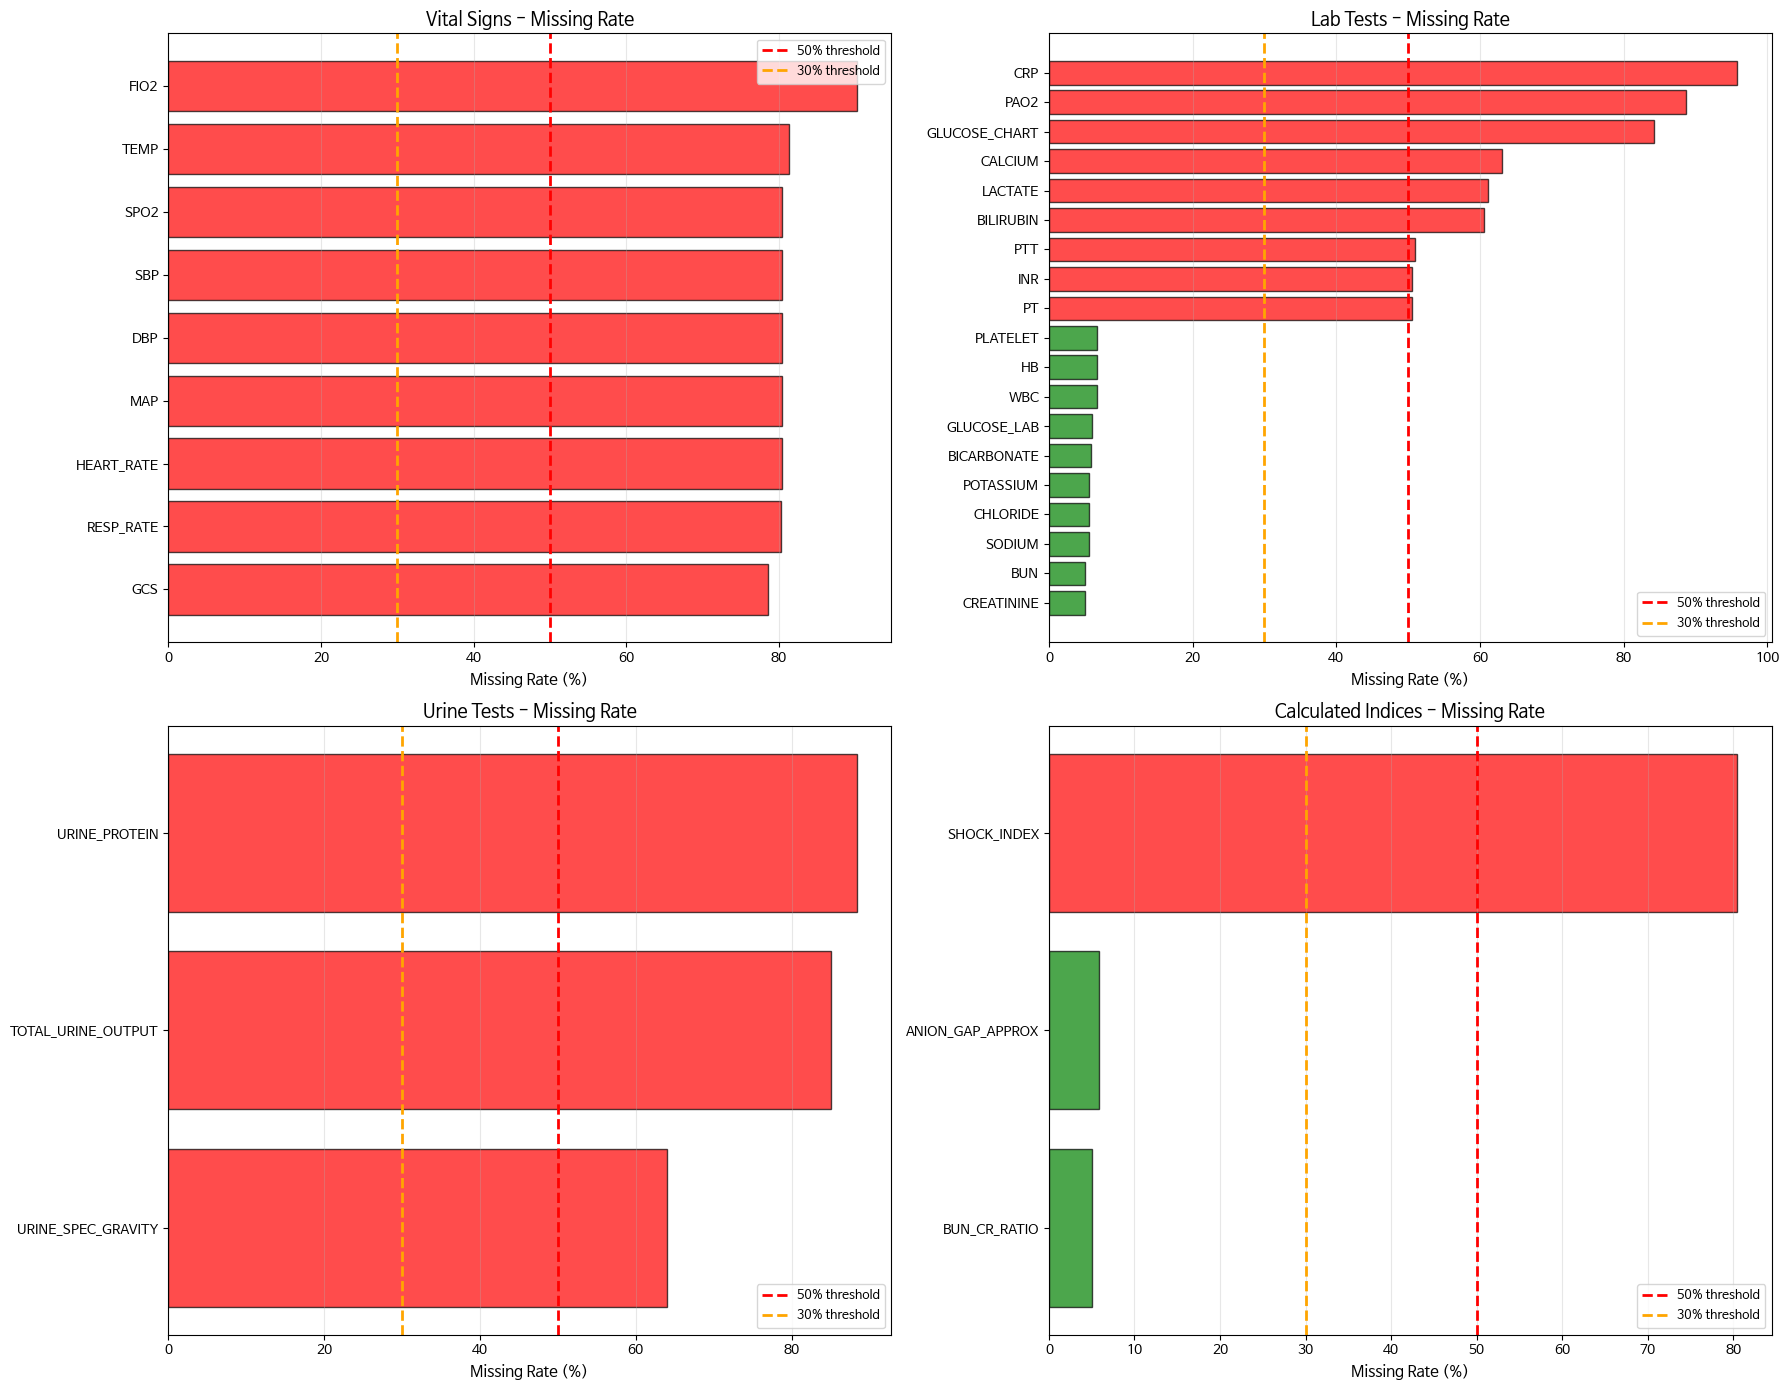

✅ 그룹별 결측률 차트 저장: missing_rate_by_group.png


In [30]:
# =============================================================================
# 6. 시각화
# =============================================================================
print("\n" + "=" * 80)
print("📈 시각화 생성 중...")
print("=" * 80)

# Figure 1: 그룹별 결측률 비교
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Vital Signs
ax = axes[0, 0]
vital_data = all_missing[all_missing['Group'] == 'Vital Signs'].sort_values('Missing_Rate(%)')
colors = ['red' if x > 50 else 'orange' if x > 30 else 'green' for x in vital_data['Missing_Rate(%)']]
ax.barh(vital_data['Variable'], vital_data['Missing_Rate(%)'], color=colors, edgecolor='black', alpha=0.7)
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='30% threshold')
ax.set_xlabel('Missing Rate (%)', fontsize=11, fontweight='bold')
ax.set_title('Vital Signs - Missing Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Lab Tests
ax = axes[0, 1]
lab_data = all_missing[all_missing['Group'] == 'Lab Tests'].sort_values('Missing_Rate(%)')
colors = ['red' if x > 50 else 'orange' if x > 30 else 'green' for x in lab_data['Missing_Rate(%)']]
ax.barh(lab_data['Variable'], lab_data['Missing_Rate(%)'], color=colors, edgecolor='black', alpha=0.7)
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='30% threshold')
ax.set_xlabel('Missing Rate (%)', fontsize=11, fontweight='bold')
ax.set_title('Lab Tests - Missing Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Urine Tests
ax = axes[1, 0]
urine_data = all_missing[all_missing['Group'] == 'Urine Tests'].sort_values('Missing_Rate(%)')
colors = ['red' if x > 50 else 'orange' if x > 30 else 'green' for x in urine_data['Missing_Rate(%)']]
ax.barh(urine_data['Variable'], urine_data['Missing_Rate(%)'], color=colors, edgecolor='black', alpha=0.7)
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='30% threshold')
ax.set_xlabel('Missing Rate (%)', fontsize=11, fontweight='bold')
ax.set_title('Urine Tests - Missing Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Calculated Indices
ax = axes[1, 1]
calc_data = all_missing[all_missing['Group'] == 'Calculated'].sort_values('Missing_Rate(%)')
colors = ['red' if x > 50 else 'orange' if x > 30 else 'green' for x in calc_data['Missing_Rate(%)']]
ax.barh(calc_data['Variable'], calc_data['Missing_Rate(%)'], color=colors, edgecolor='black', alpha=0.7)
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='30% threshold')
ax.set_xlabel('Missing Rate (%)', fontsize=11, fontweight='bold')
ax.set_title('Calculated Indices - Missing Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('missing_rate_by_group.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 그룹별 결측률 차트 저장: missing_rate_by_group.png")
